# Aplicando o algortimo CMA em diversas funções

O objetivo desse notebook é implementar o algortimo em mais 6 funções a fim de comparar o desempenho e possibilitar o *benchmarking* com outros algoritmos.

**Autor:** Edélio Gabriel Magalhães de Jesus.

## Módulo para implementação do algoritmo

Neste *notebook* usaremos o módulo `pycma` [[1]](#ref-pycma), desenvolvido por Nikolaus Hansen - um dos formuladores do CMA.
A escolha foi baseada no maior alinhamento com o algoritmo original, existindo suporte para restrições não lineares, ruídos e variações discretas.

In [11]:
import numpy as np
import cma

### **Função para aplicar o algoritmo**

In [12]:
def run_cma(function, x_min, x_max, dim, max_evals, sigma, seed=367):
    evals = 0
    historico = []

    rng = np.random.default_rng(seed)

    def f(x):
        nonlocal evals
        evals += 1
        return function(x)
    
    x0 = rng.uniform(x_min, x_max, dim)
    popsize = 4 + int(3 * np.log(dim))
    sigma = sigma * (x_max - x_min)

    optimizer = cma.CMAEvolutionStrategy(
        x0, sigma, 
        {'popsize': popsize, 'verb_disp': 0, 'seed': int(seed) if seed is not None else 0}
    )

    best = float('inf')

    while evals + popsize <= max_evals:
        X = optimizer.ask() # Amostra os pontos
        fvals = [f(x) for x in X]

        optimizer.tell(X, fvals) # Conta como foi o desempenho

        best = min(best, min(fvals)) # Salva o melhor valor
        historico.append(best)

    return best, evals, historico

`NOTAS`

`popsize`: Dado a necessídade de reprodutibilidade, definiu-se o tamanho da população de pontos amostrados como 

````python
    popsize = 4 + int(3 * np.log(dim)),
````

tendo como base a referência [[2]](#ref-cma-tutorial).

## Função para *plotar* gráfico

In [13]:
from plot_painel_functions import plot_painel, plot_painel_dimensional

## Funções de análise

Para esse *notebook*, foram elencadas 7 funções, separadas nas seguintes classes:

`Muitos mínimos locais`

- Levy
- Rastrigin
- Schwefel

`Forma de vale`:

- Rosenbrock

`Convexa`:

- Sphere 

A partir desses casos, podemos construir uma boa fundamentação para comparar o CMA com outros algoritmos de otimização *derivate-free*.

---

Vamos definir alguns parâmetros gerais

In [14]:
SEED = 367
sigma = 0.5
dims = [5, 10, 20, 50, 100]
max_evals = 5000
n_iter = 100

`NOTA`:

Os intervalos de amostragem serão definidos conforme a especificidade de cada função, tendo como base a referência [[3]](#ref-library).

---

### **Função: Levy**

<div style="text-align: center;">
  <img src="https://www.sfu.ca/~ssurjano/levy.png" alt="Função de Levy" width="500">
</div>

[Fonte: Virtual Library of Simulation Experiments](https://www.sfu.ca/~ssurjano/index.html)

$$
f(x) = \sin^2(\pi w_1) + \sum_{i=1}^{d-1}(w_i - 1)^2[1+ 10sin^2(\pi w_i + 1)] + (w_d - 1)^2[1 + \sin^2(2\pi w_d)]
$$

onde

$$
w_i = 1 + \frac{x_i -1}{4}
$$

para $i = 1, ..., d$.

In [15]:
def levy(x):
    x = np.asarray(x, dtype=float)
    w = 1 + (x - 1) / 4
    
    term1 = np.sin(np.pi * w[0])**2
    
    term2 = np.sum(
        (w[:-1] - 1)**2 * (1 + 10 * np.sin(np.pi * w[:-1] + 1)**2)
    )
    
    term3 = (w[-1] - 1)**2 * (1 + np.sin(2 * np.pi * w[-1])**2)
    
    return term1 + term2 + term3

In [16]:
hist_levy = {}

for dim in dims:
    hist_dim = []

    for i in range(n_iter):
        seed = SEED + i

        best, evals, hist = run_cma(
            function=levy,
            x_min=-10, x_max=10,
            dim=dim,
            max_evals=max_evals,
            sigma=sigma,
            seed=seed
        )

        hist_dim.append(hist)

    hist_levy[dim] = np.array(hist_dim)

---

``Vamos plotar os resultados``

---

Primeiro, escolheremos os dados coletados para uma dimensão fixada. Para essa e as demais análises, escolheremos a otimização para 20 dimensões.

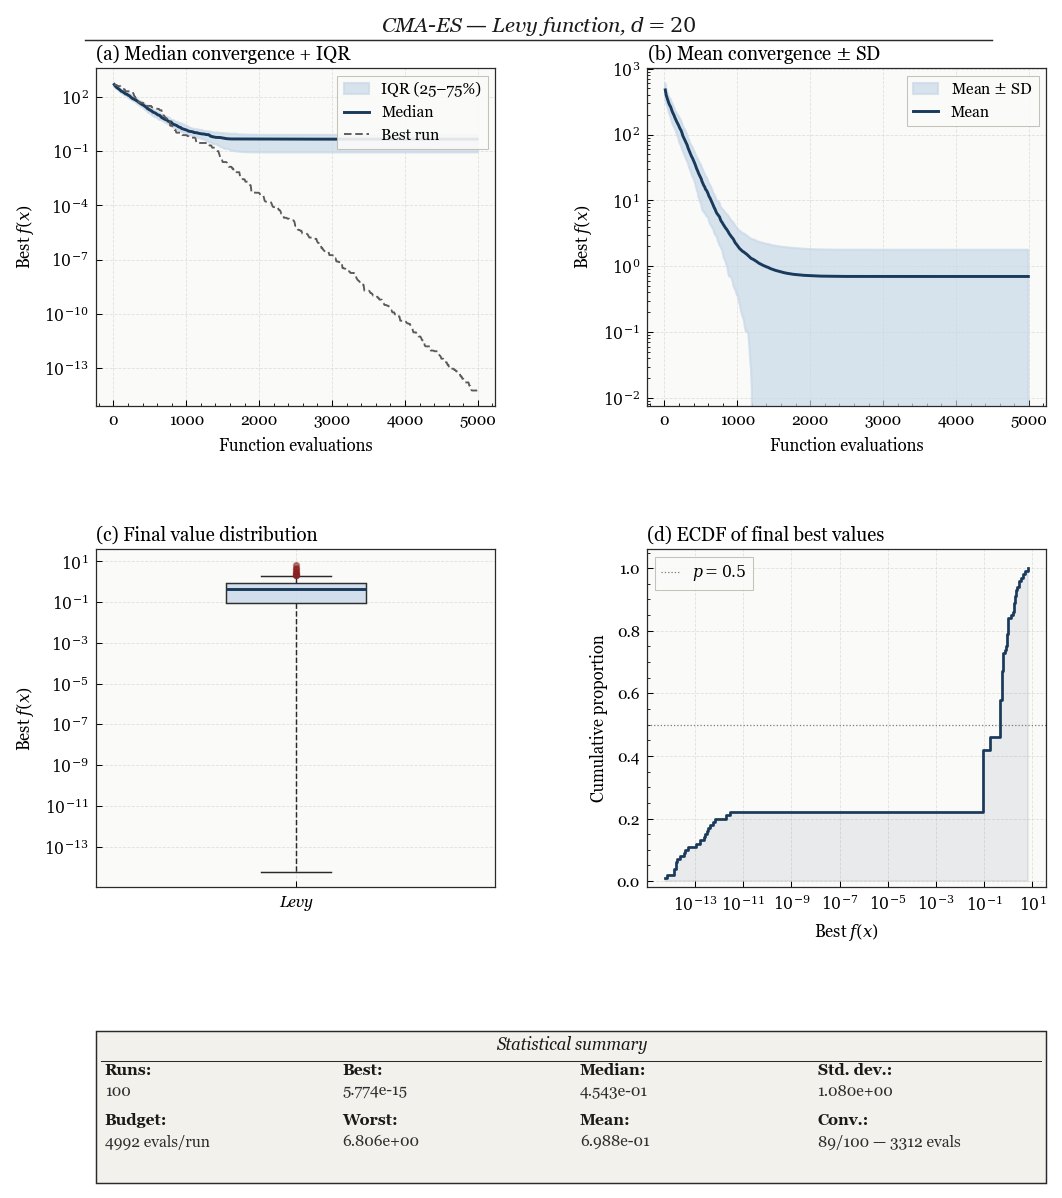

In [17]:
plot_painel(hist_levy[20], func='Levy', dim=20)

Agora, olharemos para como o Algoritmo se comporta quando escalamos o número de dimensões.

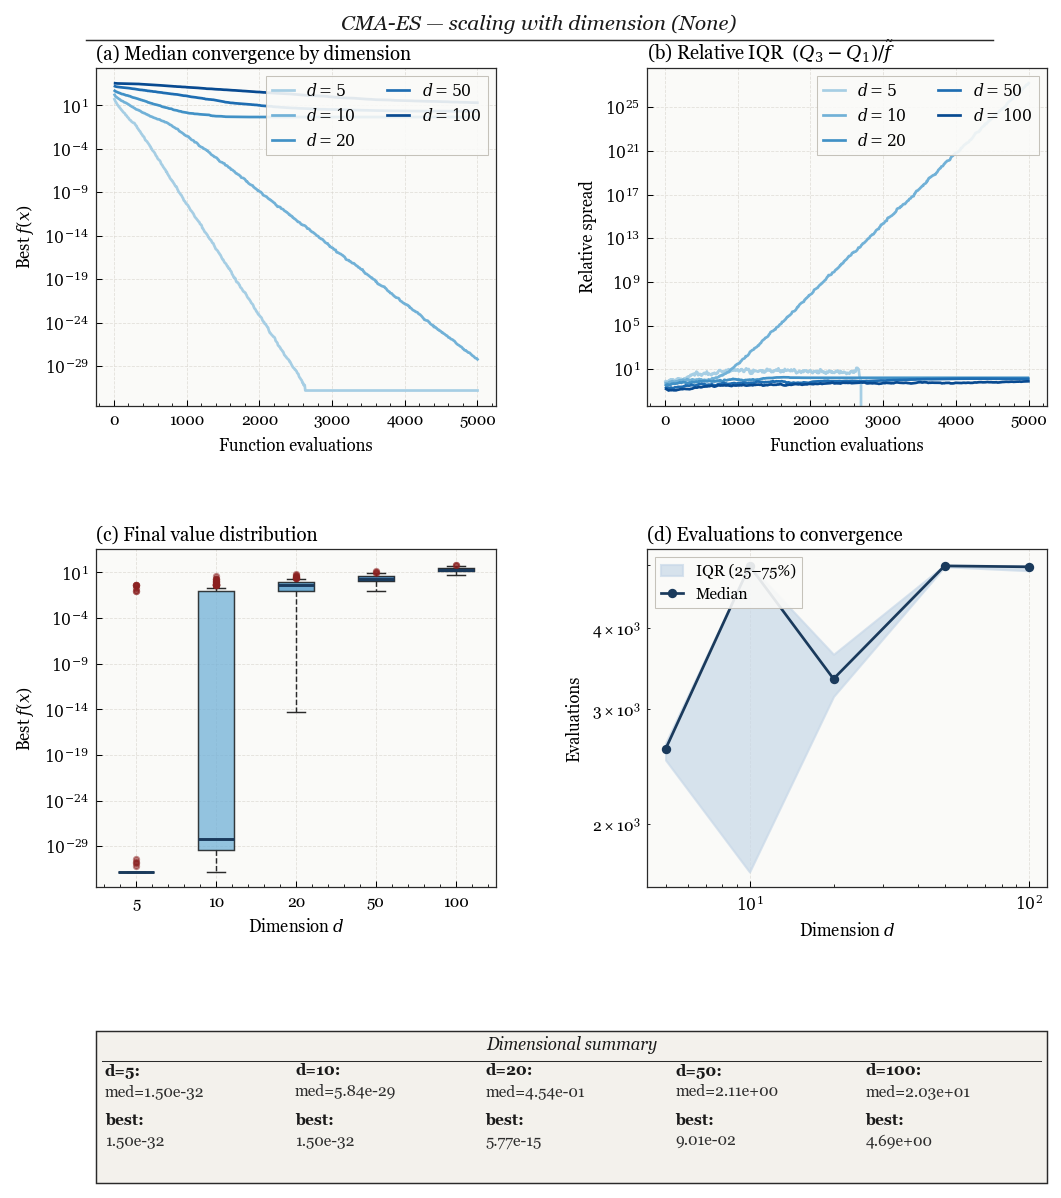

In [18]:
plot_painel_dimensional(hist_levy)

### **Função Rastrigin**

<div style="text-align: center;">
  <img src="https://www.sfu.ca/~ssurjano/rastr.png" alt="Função de Levy" width="500">
</div>

[Fonte: Virtual Library of Simulation Experiments](https://www.sfu.ca/~ssurjano/index.html)

$$
f(x) = 10d + \sum_{i=1}^d[x_i^2 - 10cos(2\pi x_i)]
$$

In [19]:
def rastrigin(x):
    x = np.asarray(x, dtype=float)
    d = len(x)

    return (
        10 * d + np.sum(x ** 2 - 10 * np.cos(2 * np.pi * x))
    )

In [20]:
hist_rastringin = {}

for dim in dims:
    hist_dim = []

    for i in range (n_iter):
        seed = SEED + i

        best, evals, hist = run_cma(
            function=rastrigin, 
            x_min=-5.12, x_max=5.12, 
            dim=dim, 
            max_evals=max_evals,
            sigma=sigma, 
            seed=seed
        )

        hist_dim.append(hist)

    hist_rastringin[dim] = np.array(hist_dim)
    

---

Vamos visualizar os resultados

---

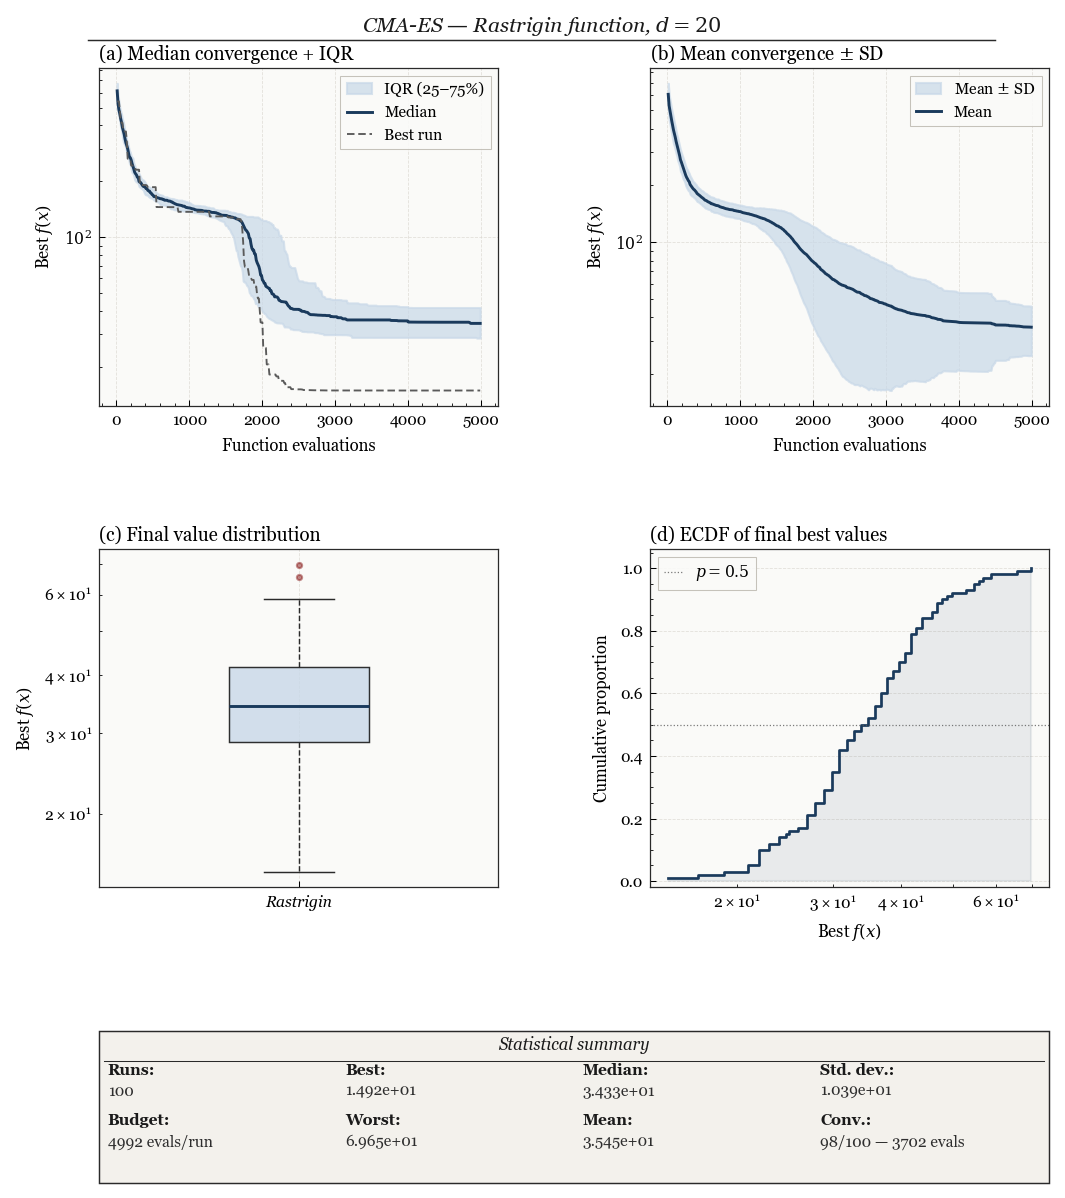

In [21]:
plot_painel(hist_rastringin[20], func='Rastrigin', dim=20)

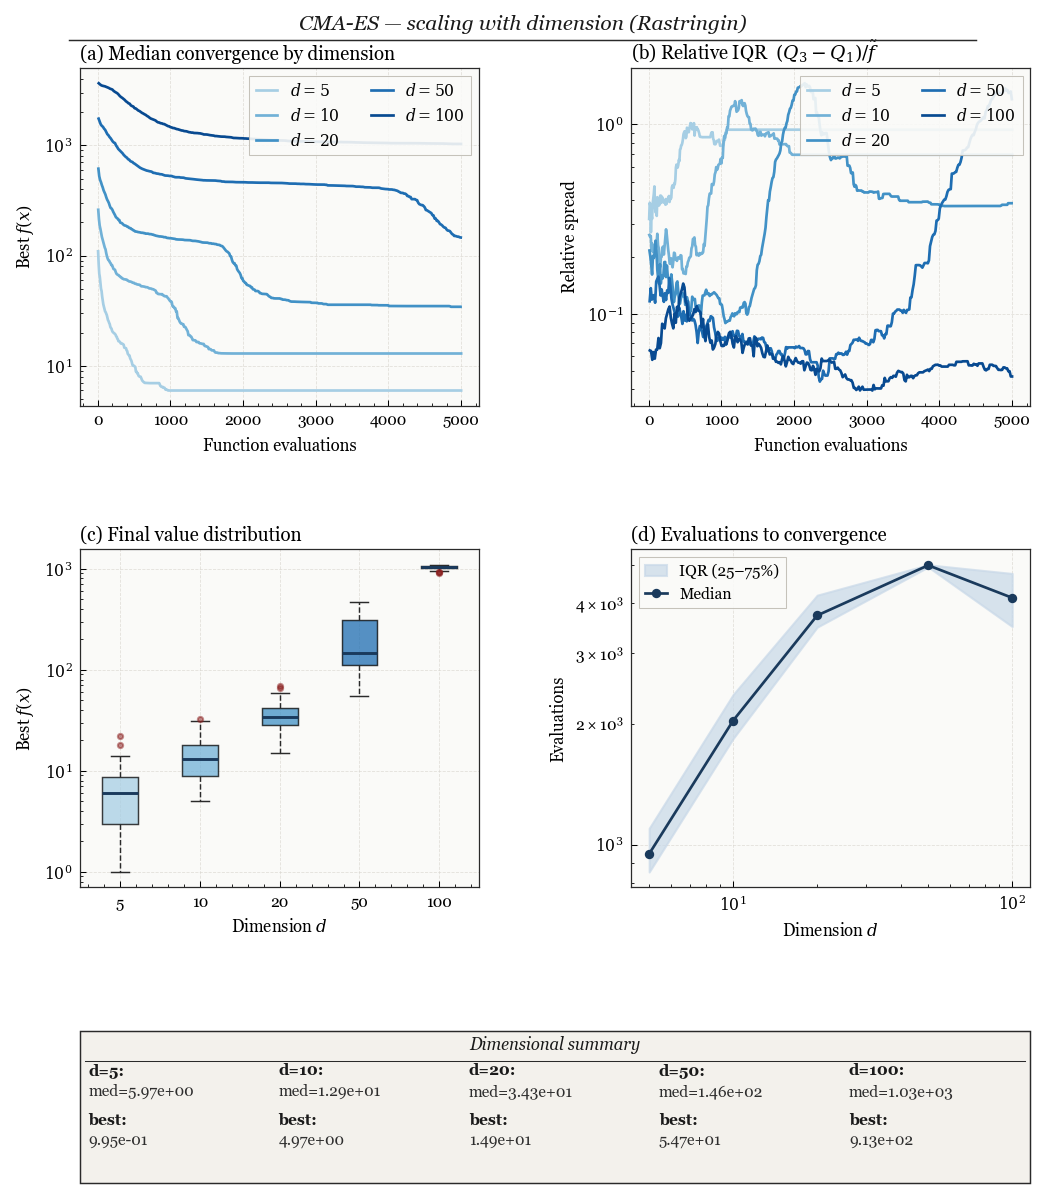

In [22]:
plot_painel_dimensional(hist_rastringin, func='Rastringin')

### **Função Schwefel**

<div style="text-align: center;">
  <img src="https://www.sfu.ca/~ssurjano/schwef.png" alt="Função de Levy" width="500">
</div>

[Fonte: Virtual Library of Simulation Experiments](https://www.sfu.ca/~ssurjano/index.html)

$$
f(x) = 418.9829d - \sum_{i=1}^dx_i\sin(\sqrt(|x_i|))
$$

In [23]:
def schwefel(x):
    x = np.asarray(x, dtype=float)
    d = x.size
    
    return 418.9829 * d - np.sum(x * np.sin(np.sqrt(np.abs(x))))

In [47]:
hist_schwefel = {}

for dim in dims:
    hist_dim = []

    for i in range (n_iter):
        seed = SEED + i

        best, evals, hist = run_cma(function=schwefel, 
                                    x_min=-500, x_max=500, 
                                    dim=dim, 
                                    max_evals=max_evals,
                                    sigma=0.05, 
                                    seed=seed)
        
        hist_dim.append(hist)

    hist_schwefel[dim] = np.array(hist_dim)

In [48]:
hist_schwefel[20]

array([[7043.29606627, 6165.10530148, 5097.94232632, ..., 3613.05642719,
        3613.05642719, 3613.05642719],
       [6759.28286758, 6759.28286758, 6490.10248268, ..., 3434.92840883,
        3434.92840883, 3434.92840883],
       [7237.28845114, 5746.20936547, 5113.98189216, ..., 2625.47588242,
        2625.47588242, 2625.47588242],
       ...,
       [7101.91895622, 7101.91895622, 6738.84655112, ..., 2704.47491939,
        2704.47491939, 2704.47491939],
       [7013.04425166, 6235.45962581, 6235.45962581, ..., 3554.19792144,
        3554.19792144, 3554.19792144],
       [6675.21979523, 6382.91241861, 6382.91241861, ..., 2901.98530828,
        2901.98530828, 2901.98530828]], shape=(100, 416))

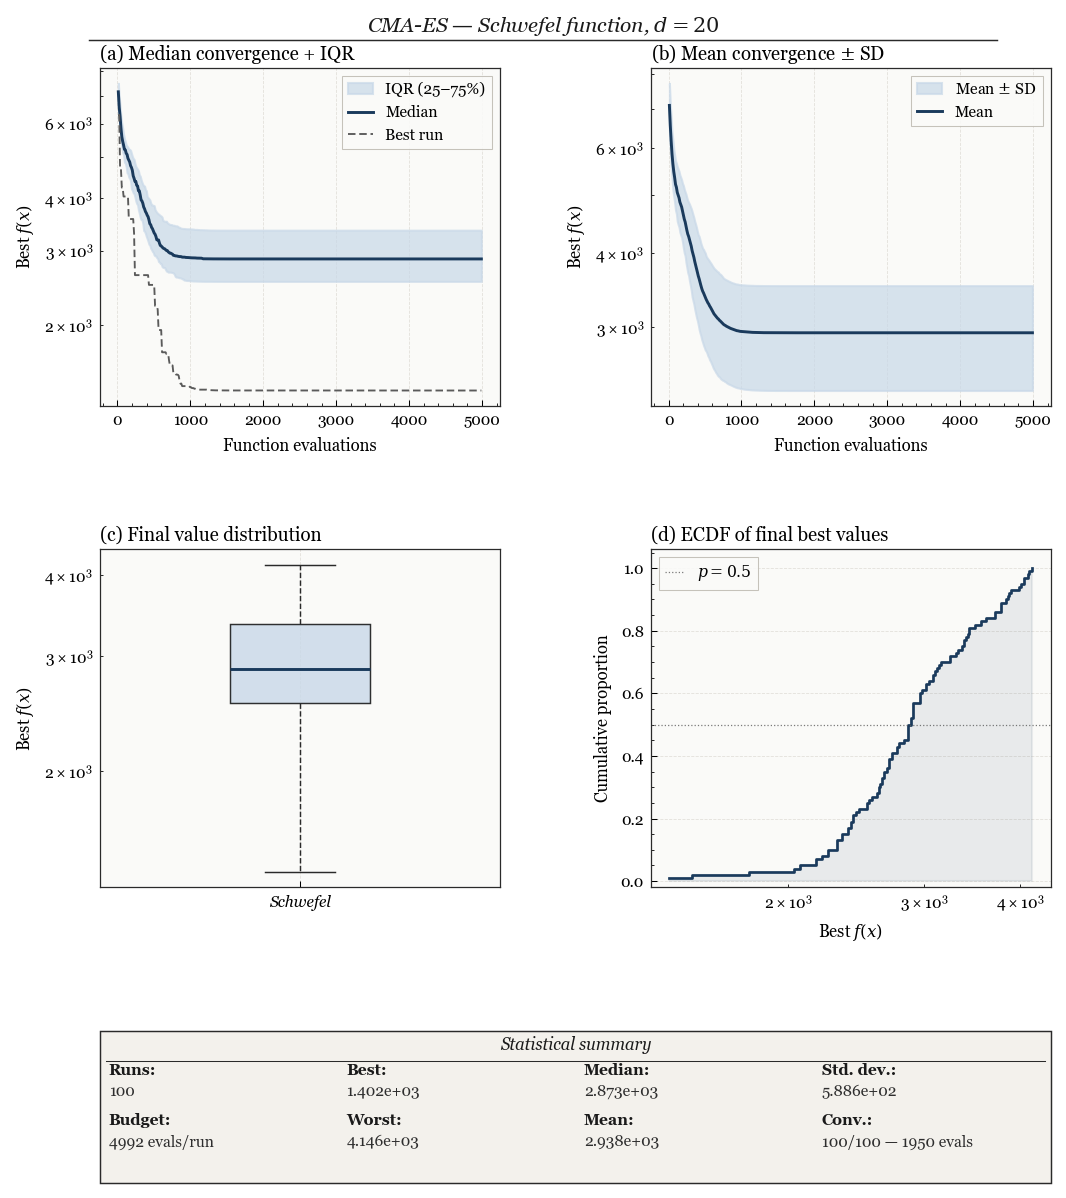

In [49]:
plot_painel(hist_schwefel[20], func='Schwefel', dim=20)

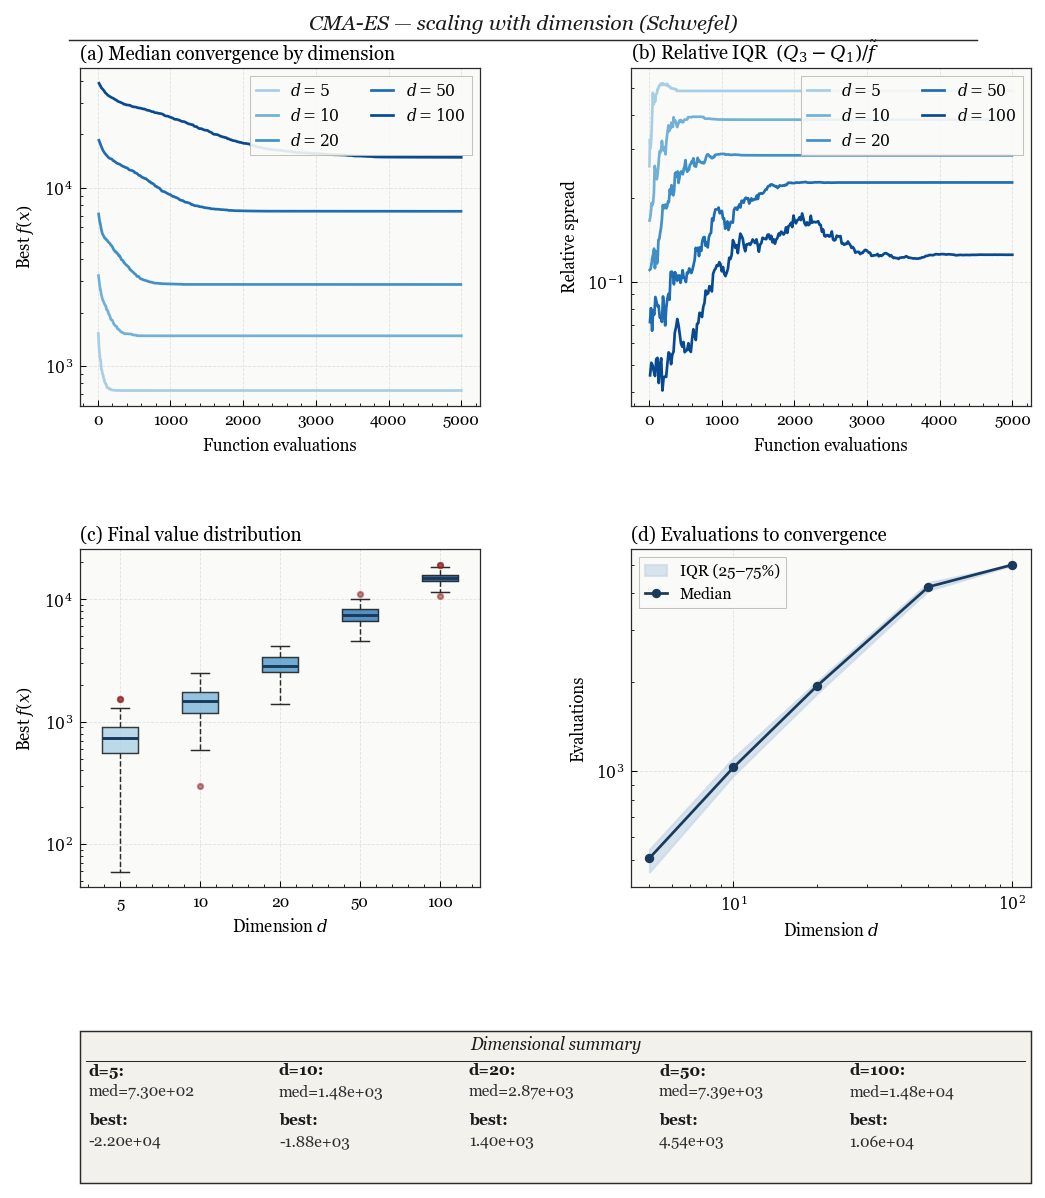

In [50]:
plot_painel_dimensional(hist_schwefel, func='Schwefel')

### **Função Rosenbrock**

<div style="text-align: center;">
  <img src="https://www.sfu.ca/~ssurjano/rosen.png" alt="Função de Levy" width="500">
</div>

[Fonte: Virtual Library of Simulation Experiments](https://www.sfu.ca/~ssurjano/index.html)

$$
f(x) = \sum_{i=1}^{d-1}[100(x_{i+1} - x_i^2)^2 + (x_i -1)^2]

In [51]:
def rosenbrock(x):
    x = np.array(x)

    return np.sum(
        100 * (x[1:] - x[:-1]**2)**2 + (x[:-1] - 1)**2
    )

---

Adivinha? Vamos olhar os resultados!

---

In [52]:
hist_rosenbrock = {}

for dim in dims:
    hist_dim = []

    for i in range (n_iter):
        seed = SEED + i

        best, evals, hist = run_cma(function=rosenbrock, 
                                    x_min=-2.048, x_max=2.048, 
                                    dim=dim, 
                                    max_evals=max_evals,
                                    sigma=sigma, 
                                    seed=seed)
        hist_dim.append(hist)

    hist_rosenbrock[dim] = np.array(hist_dim)
    

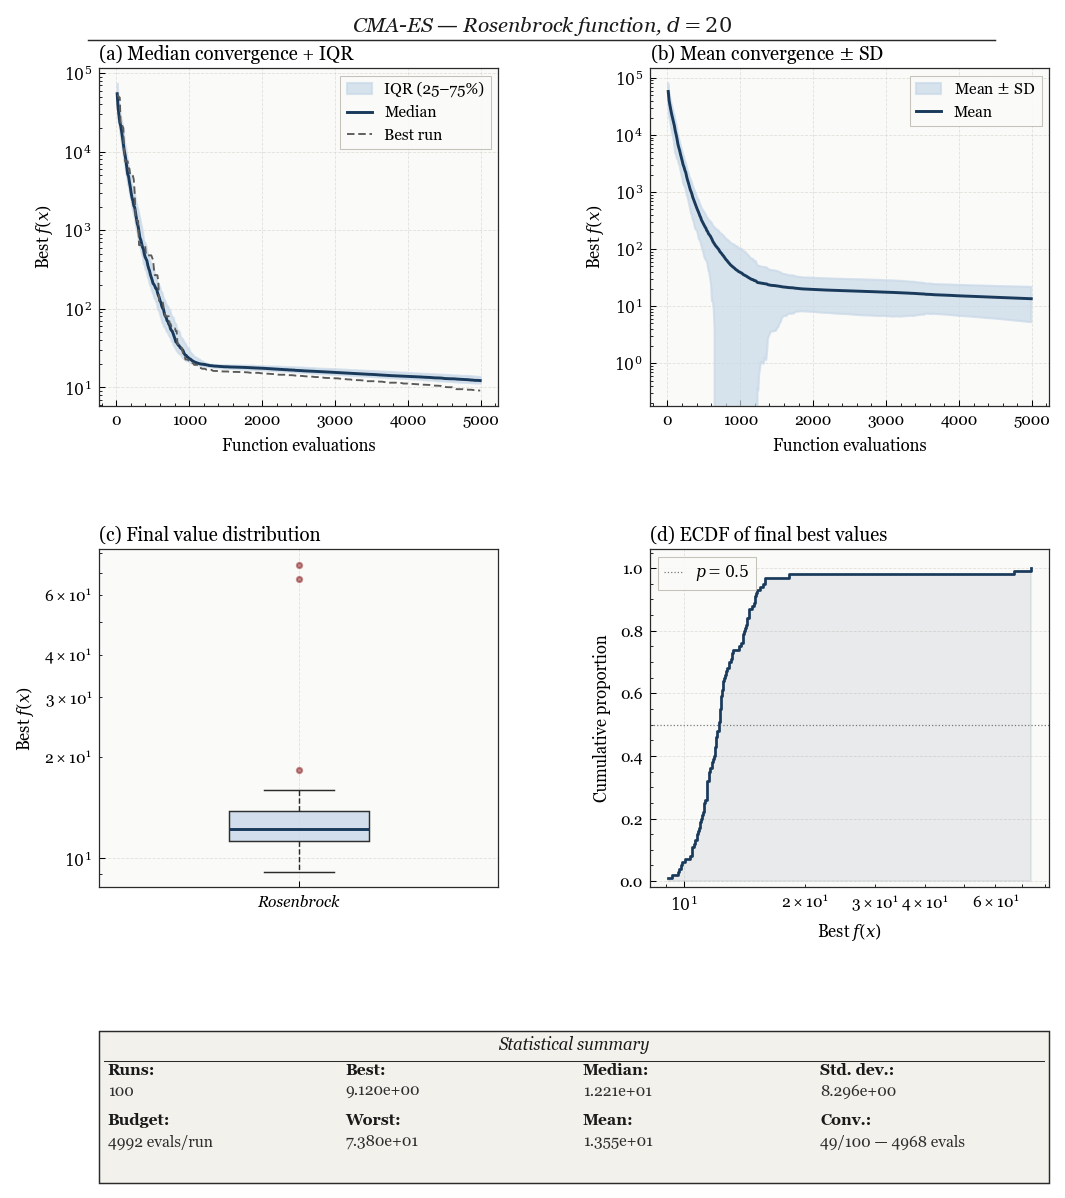

In [54]:
plot_painel(hist_rosenbrock[20], func='Rosenbrock', dim=20)

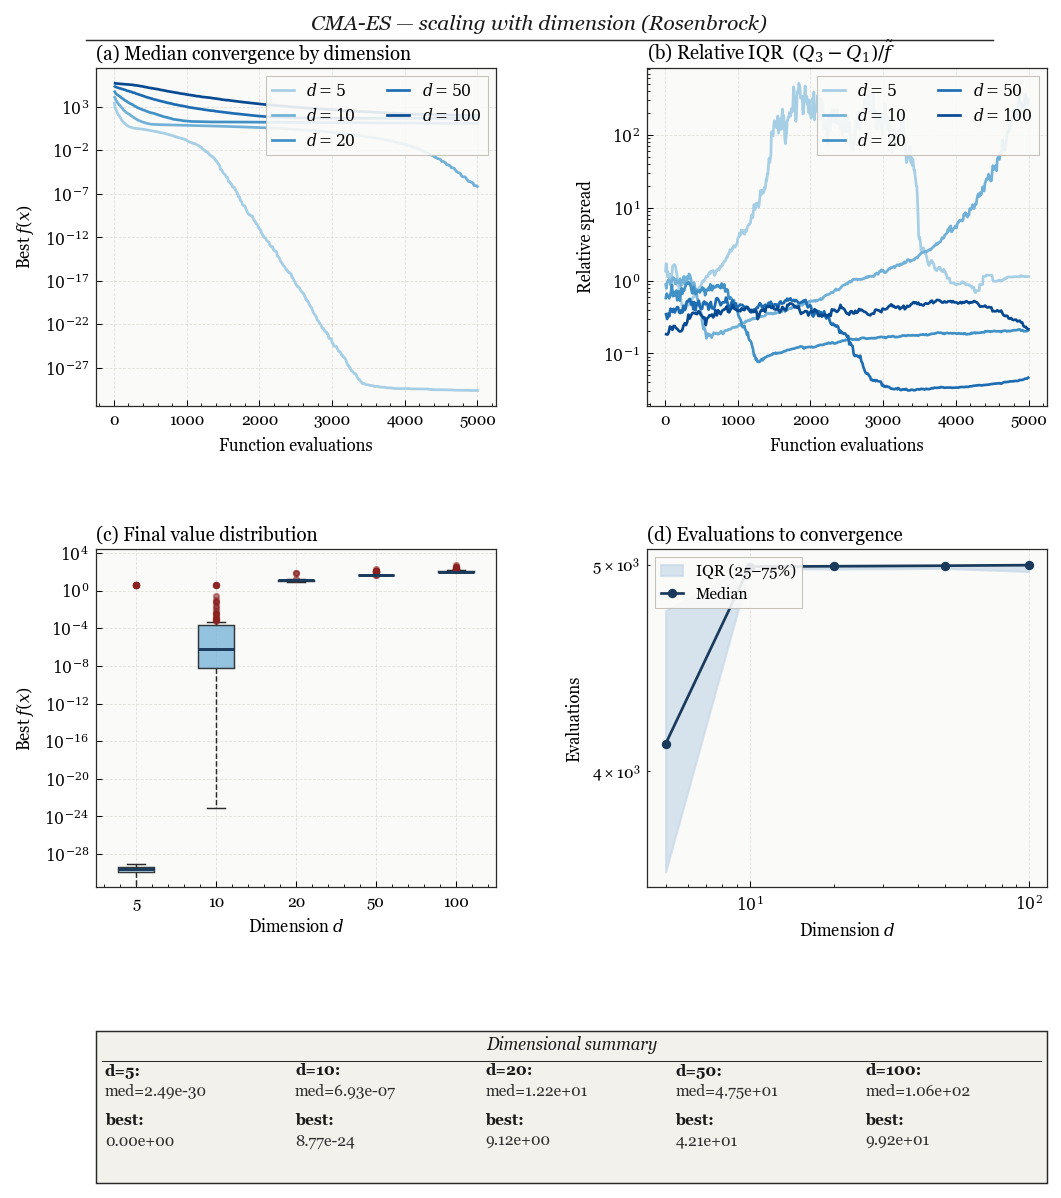

In [55]:
plot_painel_dimensional(hist_rosenbrock, func='Rosenbrock')

### **Função Sphere**

<div style="text-align: center;">
  <img src="https://www.sfu.ca/~ssurjano/spheref.png" alt="Função de Levy" width="500">
</div>

[Fonte: Virtual Library of Simulation Experiments](https://www.sfu.ca/~ssurjano/index.html)

$$
f(x) = \sum_{i=1}^dx_i^2
$$

In [56]:
def sphere(x):
    x = np.asarray(x, dtype=float)

    return (
        np.sum(x**2)
    )

In [57]:
hist_sphere = {}

for dim in dims:
    hist_dim = []

    for i in range (n_iter):
        seed = SEED + i

        best, evals, hist = run_cma(function=sphere, 
                                    x_min=-5.12, x_max=5.12, 
                                    dim=dim, 
                                    max_evals=max_evals,
                                    sigma=sigma, 
                                    seed=seed)
        
        hist_dim.append(hist)

    hist_sphere[dim] = np.array(hist_dim)    

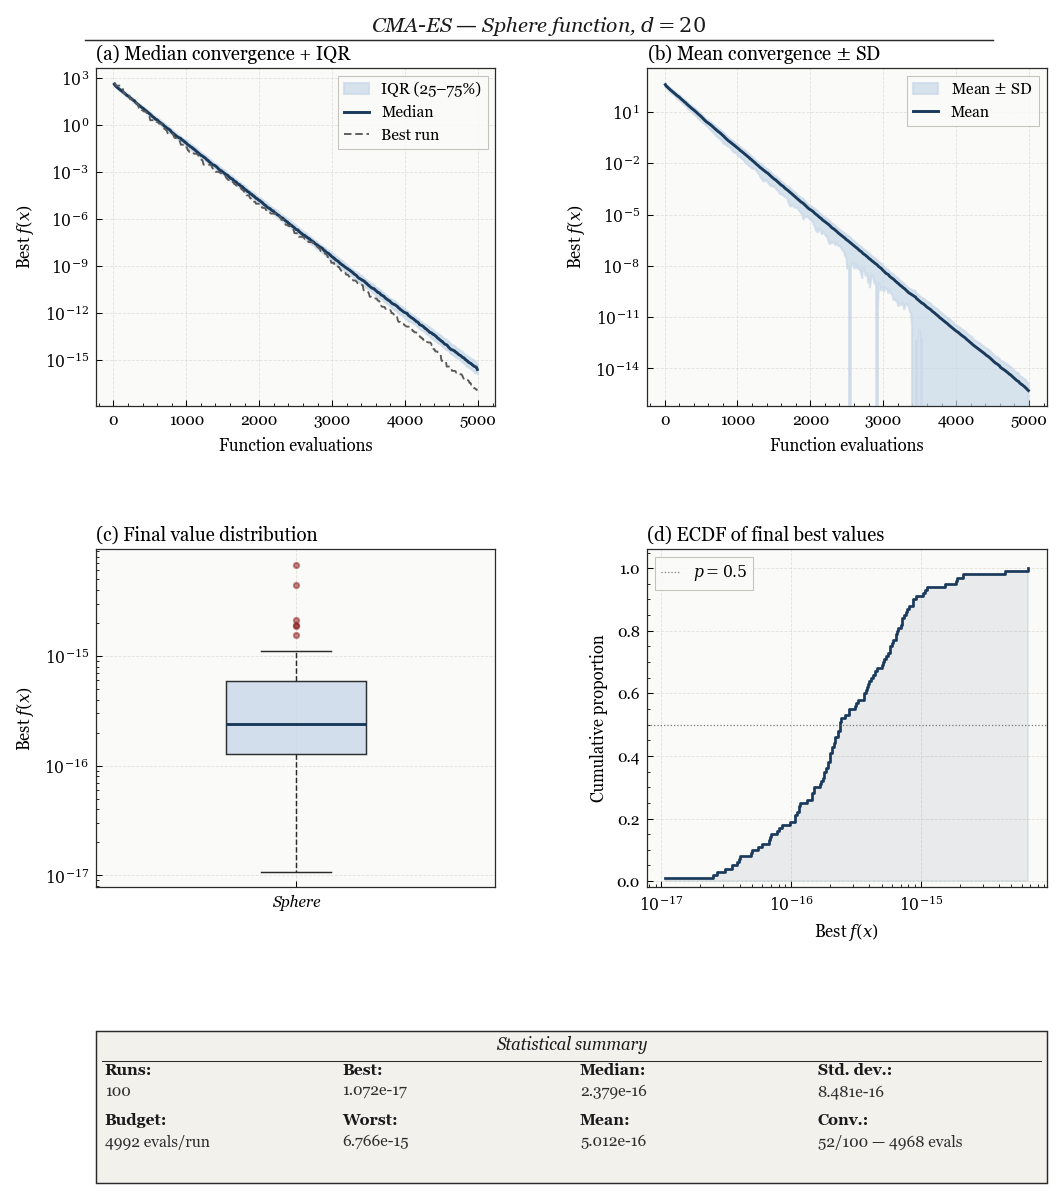

In [58]:
plot_painel(hist_sphere[20], func='Sphere',dim=20)

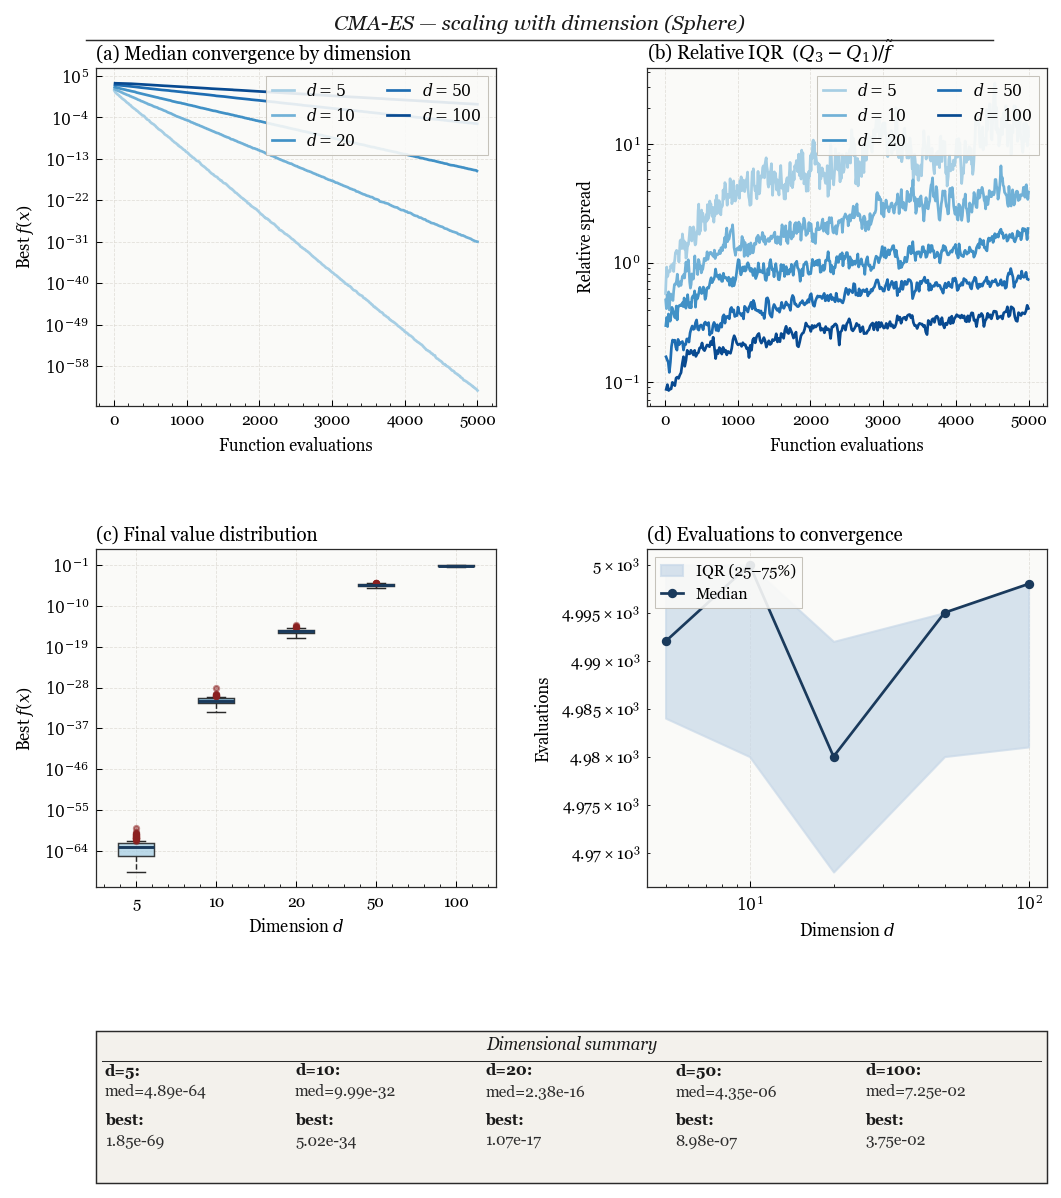

In [59]:
plot_painel_dimensional(hist_sphere, func='Sphere')

## Referências

<a id="ref-pycma"></a> [1] [CMA-ES/pycma on Github](https://doi.org/10.5281/zenodo.2559634)

<a id="ref-cma-tutorial"></a> [2] [HANSEN, Nikolaus. The CMA evolution strategy: A tutorial. arXiv preprint arXiv:1604.00772, 2016.](https://doi.org/10.48550/arXiv.1604.00772)

<a id="ref-library"></a> [3] [Virtual Library of Simulation Experiments](https://www.sfu.ca/~ssurjano/levy.html)